<a href="https://colab.research.google.com/github/traceypaulinealbert/traceypaulinealbert/blob/main/FinalProject_tpa2112.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries
!pip install requests
!pip install newspaper3k
!pip install gensim
!pip install nltk
!pip install pyLDAvis

import requests
import nltk
import pandas as pd
import numpy as np
#from newspaper import Article
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim_models
import re
import string

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
# The line below downloads the necessary 'punkt_tab' resource.
nltk.download('punkt_tab') # This is the crucial line to download punkt_tab resource


# Function to fetch news articles using NewsAPI
def fetch_news_articles(api_key, query, num_articles=100):
    url = f'https://newsapi.org/v2/everything?q={query}&pageSize={num_articles}&apiKey={api_key}'
    response = requests.get(url)
    articles = response.json()['articles']

    data = []
    for article in articles:
        title = article['title']
        description = article['description']
        content = article['content']
        data.append({'title': title, 'description': description, 'content': content})

    return pd.DataFrame(data)

# Example: Fetch news articles about South Sudan
api_key = '4ed55cd28e4349fea965dfac050ad6ef'  # You need to get a NewsAPI key from https://newsapi.org/
news_df = fetch_news_articles(api_key, 'South Sudan')

# Data Cleaning
def clean_text(text):
    # Remove non-alphabetic characters, stop words, and tokenize
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned_tokens

# Clean content for topic modeling
news_df['cleaned_content'] = news_df['content'].apply(lambda x: clean_text(str(x)))

# Prepare data for LDA Topic Modeling
texts = news_df['cleaned_content'].tolist()

# Create a dictionary and corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Apply LDA Model (Topic Modeling)
lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Visualize Topics
pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Print topics
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

# Keyword Analysis - Find most common words across articles
from collections import Counter

# Flatten list of all words
all_words = [word for text in texts for word in text]
word_counts = Counter(all_words)

# Print top 10 most common words
print(word_counts.most_common(10))

# Contextual Analysis using nltk similar() method
def find_similar_words(word, texts):
    # Create a frequency distribution of words
    all_text = ' '.join([' '.join(text) for text in texts])
    all_tokens = word_tokenize(all_text.lower())
    text_freq = nltk.FreqDist(all_tokens)

    # Get context for a specific word
    text = nltk.Text(all_tokens)
    similar_words = text.similar(word)
    return similar_words

# Example: Find words similar to 'peace'
similar_words_to_peace = find_similar_words('peace', texts)
print(similar_words_to_peace)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(0, '0.036*"chars" + 0.014*"sudan" + 0.013*"nations" + 0.011*"south" + 0.009*"million"')
(1, '0.032*"removed" + 0.029*"chars" + 0.028*"sudan" + 0.022*"south" + 0.011*"aid"')
(2, '0.029*"chars" + 0.007*"africa" + 0.007*"law" + 0.006*"south" + 0.004*"council"')
(3, '0.028*"chars" + 0.014*"sudan" + 0.012*"south" + 0.008*"security" + 0.007*"two"')
(4, '0.032*"chars" + 0.021*"sudan" + 0.015*"south" + 0.008*"juba" + 0.008*"capital"')
[('chars', 82), ('sudan', 42), ('south', 35), ('nations', 19), ('removed', 17), ('united', 14), ('november', 11), ('security', 10), ('aid', 9), ('war', 9)]

None


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(0, '0.025*"chars" + 0.015*"sudan" + 0.013*"south" + 0.010*"united" + 0.008*"people"')
(1, '0.023*"chars" + 0.009*"affairs" + 0.006*"refugees" + 0.006*"crisis" + 0.006*"security"')
(2, '0.034*"chars" + 0.014*"sudan" + 0.012*"south" + 0.009*"nations" + 0.008*"un"')
(3, '0.037*"chars" + 0.032*"sudan" + 0.026*"south" + 0.011*"juba" + 0.009*"nations"')
(4, '0.033*"removed" + 0.030*"chars" + 0.006*"year" + 0.006*"united" + 0.006*"nations"')
[('chars', 82), ('sudan', 42), ('south', 35), ('nations', 19), ('removed', 17), ('united', 14), ('november', 11), ('security', 10), ('aid', 9), ('war', 9)]

None
[('chars', 82), ('sudan', 42), ('south', 35), ('nations', 19), ('removed', 17), ('united', 14), ('november', 11), ('security', 10), ('aid', 9), ('war', 9)]


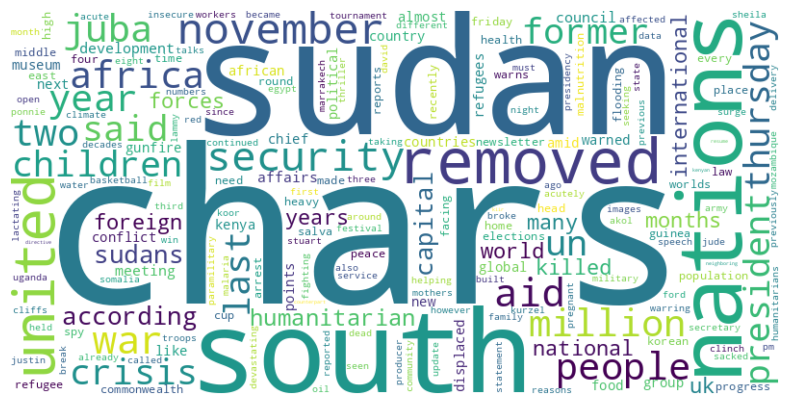

In [ ]:
import requests
import nltk
import pandas as pd
import numpy as np
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim_models
import re
import string

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # This is the crucial line to download punkt_tab resource

# Function to fetch news articles using NewsAPI
def fetch_news_articles(api_key, query, num_articles=100):
    url = f'https://newsapi.org/v2/everything?q={query}&pageSize={num_articles}&apiKey={api_key}'
    response = requests.get(url)
    articles = response.json()['articles']

    data = []
    for article in articles:
        title = article['title']
        description = article['description']
        content = article['content']
        data.append({'title': title, 'description': description, 'content': content})

    return pd.DataFrame(data)

# Example: Fetch news articles about South Sudan
api_key = '4ed55cd28e4349fea965dfac050ad6ef'  # Replace with your NewsAPI key
news_df = fetch_news_articles(api_key, 'South Sudan')

# Data Cleaning
def clean_text(text):
    # Remove non-alphabetic characters, stop words, and tokenize
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned_tokens

# Clean content for topic modeling
news_df['cleaned_content'] = news_df['content'].apply(lambda x: clean_text(str(x)))

# Prepare data for LDA Topic Modeling
texts = news_df['cleaned_content'].tolist()

# Create a dictionary and corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Apply LDA Model (Topic Modeling)
lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Visualize Topics
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Display the visualization in Google Colab
pyLDAvis.display(lda_vis)

# Print topics
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

# Keyword Analysis - Find most common words across articles
from collections import Counter

# Flatten list of all words
all_words = [word for text in texts for word in text]
word_counts = Counter(all_words)

# Print top 10 most common words
print(word_counts.most_common(10))

# Contextual Analysis using nltk similar() method
def find_similar_words(word, texts):
    # Create a frequency distribution of words
    all_text = ' '.join([' '.join(text) for text in texts])
    all_tokens = word_tokenize(all_text.lower())
    text_freq = nltk.FreqDist(all_tokens)

    # Get context for a specific word
    text = nltk.Text(all_tokens)
    similar_words = text.similar(word)
    return similar_words

# Example: Find words similar to 'peace'
similar_words_to_peace = find_similar_words('peace', texts)
print(similar_words_to_peace)
# Importing necessary libraries for WordCloud and visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Importing necessary libraries for WordCloud and visualization
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Assuming `texts` is a list of cleaned text tokens (from your earlier data processing steps)

# Flatten the list of all words from the texts
all_words = [word for text in texts for word in text]

# Count the frequency of each word using Counter
word_counts = Counter(all_words)

# Print the top 10 most common words
print(word_counts.most_common(10))

# --- WordCloud Visualization ---
# Create a WordCloud from the most common words
wordcloud_data = dict(word_counts)  # Convert Counter to dictionary for WordCloud

# Create WordCloud object with desired settings (width, height, background color)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

# Plot the WordCloud
plt.figure(figsize=(10, 5))  # Set the size of the figure
plt.imshow(wordcloud, interpolation='bilinear')  # Display the WordCloud
plt.axis('off')  # Turn off the axis
plt.show()  # Show the plot


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(0, '0.036*"chars" + 0.026*"south" + 0.025*"sudan" + 0.012*"million" + 0.012*"juba"')
(1, '0.034*"chars" + 0.020*"sudan" + 0.010*"november" + 0.008*"crisis" + 0.008*"war"')
(2, '0.034*"removed" + 0.027*"chars" + 0.016*"sudan" + 0.010*"nations" + 0.009*"south"')
(3, '0.029*"chars" + 0.024*"south" + 0.016*"nations" + 0.013*"year" + 0.011*"united"')
(4, '0.028*"chars" + 0.007*"united" + 0.005*"forces" + 0.005*"sudans" + 0.005*"korean"')
[('chars', 83), ('sudan', 42), ('south', 37), ('nations', 19), ('removed', 16), ('united', 14), ('november', 11), ('security', 10), ('aid', 9), ('war', 9)]


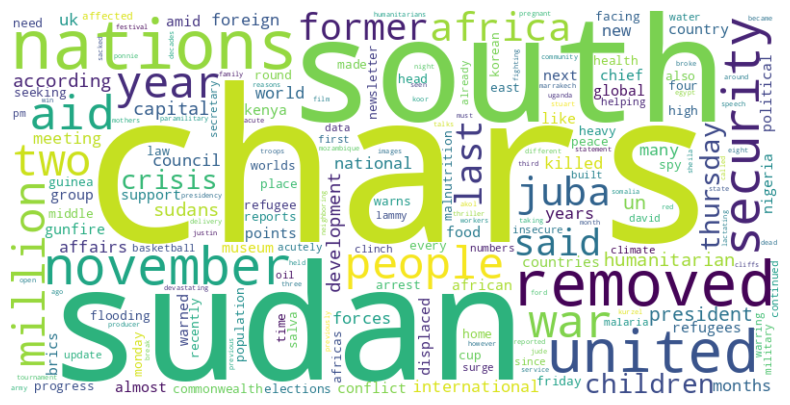


None

Concordance results for 'chars':
Displaying 83 of 83 matches:
ers face drink water dirty place oil chars uk foreign secretary david lammy sai
sh first comments since commonwealth chars flooding south sudan displaced peopl
 said worlds youngest country highly chars nov pm et miami serbian national tea
k floor club helped clinch spot next chars almost percent south sudans populati
rns data united nationsbacked review chars sudans footballers defied nations ci
ound matches also saw benin progress chars archaeological garden sudan national
y name national museum reflect story chars climate change helping drive rising 
report threequarters worlds forcibly chars united nations said continued weapon
top civilians bearing brunt conflict chars fighting broke south sudan capital j
ecurity service nss fired last month chars refugees currently seeking protectio
 kenya slowly becoming hostile place chars people killed many others feared dea
s society said thursday least bodies chars removed 

In [ ]:
import requests
import nltk
import pandas as pd
import numpy as np
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim_models
import re
import string
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # This is the crucial line to download punkt_tab resource

# Function to fetch news articles using NewsAPI
def fetch_news_articles(api_key, query, num_articles=100):
    url = f'https://newsapi.org/v2/everything?q={query}&pageSize={num_articles}&apiKey={api_key}'
    response = requests.get(url)
    articles = response.json()['articles']

    data = []
    for article in articles:
        title = article['title']
        description = article['description']
        content = article['content']
        data.append({'title': title, 'description': description, 'content': content})

    return pd.DataFrame(data)

# Example: Fetch news articles about South Sudan
api_key = '4ed55cd28e4349fea965dfac050ad6ef'  # Replace with your NewsAPI key
news_df = fetch_news_articles(api_key, 'South Sudan')

# Data Cleaning
def clean_text(text):
    # Remove non-alphabetic characters, stop words, and tokenize
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned_tokens

# Clean content for topic modeling
news_df['cleaned_content'] = news_df['content'].apply(lambda x: clean_text(str(x)))

# Prepare data for LDA Topic Modeling
texts = news_df['cleaned_content'].tolist()

# Create a dictionary and corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Apply LDA Model (Topic Modeling)
lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Visualize Topics
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Display the visualization in Google Colab
pyLDAvis.display(lda_vis)

# Print topics
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

# Keyword Analysis - Find most common words across articles
# Flatten list of all words
all_words = [word for text in texts for word in text]
word_counts = Counter(all_words)
stop_words = set(stopwords.words('english'))
stop_words.add('south')
stop_words.add('sudan')
stop_words.add('chars')

# Print top 10 most common words
print(word_counts.most_common(10))

# --- WordCloud Visualization ---
# Create a WordCloud from the most common words
wordcloud_data = dict(word_counts)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axes
plt.show()

# Contextual Analysis using nltk similar() method
def find_similar_words(word, texts):
    # Create a frequency distribution of words
    all_text = ' '.join([' '.join(text) for text in texts])
    all_tokens = word_tokenize(all_text.lower())
    text_freq = nltk.FreqDist(all_tokens)

    # Get context for a specific word
    text = nltk.Text(all_tokens)
    similar_words = text.similar(word)
    return similar_words

# Example: Find words similar to 'peace'
similar_words_to_peace = find_similar_words('peace', texts)
print(similar_words_to_peace)

# --- Additional Concordance Analysis for 'chars' ---
# Create an NLTK Text object from the combined cleaned content
all_cleaned_text = ' '.join(news_df['cleaned_content'].dropna().apply(lambda x: ' '.join(x)))
nltk_text = nltk.Text(word_tokenize(all_cleaned_text.lower()))  # Tokenize the combined text

# Perform Concordance Search for the word 'chars'
print("\nConcordance results for 'chars':")
nltk_text.concordance('chars', width=80, lines=83)  # 80-width context window, 83 lines of output


In [ ]:
# --- Full Sentence Extraction for 'chars' ---
from nltk.tokenize import sent_tokenize  # Import sent_tokenize

def extract_full_sentences(word, text):
    # Tokenize the content into sentences
    sentences = sent_tokenize(text) # assign sent_tokenize(text) to sentences

    # Find sentences containing the word 'chars'
    sentences_with_word = [sentence for sentence in sentences if word in sentence.lower()]
    return sentences_with_word

# Extract full sentences containing 'chars'
full_sentences_with_chars = extract_full_sentences('chars', all_cleaned_text)

# Print the full sentences containing the word 'chars'
print("\nFull sentences containing 'chars':")
for sentence in full_sentences_with_chars:
    print(sentence)


Full sentences containing 'chars':
herders scooping murky water small pond grasslands south sudan well aware dangers face drink water dirty place oil chars uk foreign secretary david lammy said concept reparations former colonial nations affected slavery transfer cash first comments since commonwealth chars flooding south sudan displaced people according united nations update warned surge malaria aid agencies said worlds youngest country highly chars nov pm et miami serbian national team player lost kidney last years basketball world cup back floor club helped clinch spot next chars almost percent south sudans population acutely food insecure next year two million children risk malnutrition warns data united nationsbacked review chars sudans footballers defied nations civil war clinch remarkable qualification africa cup nations tense last round matches also saw benin progress chars archaeological garden sudan national museum image rawya saeed two museums africa built midtwentieth cent

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(0, '0.013*"aid" + 0.010*"humanitarian" + 0.008*"president" + 0.008*"children" + 0.008*"people"')
(1, '0.010*"security" + 0.008*"war" + 0.008*"former" + 0.008*"african" + 0.008*"development"')
(2, '0.005*"year" + 0.005*"gunfire" + 0.005*"two" + 0.005*"africa" + 0.005*"crisis"')
(3, '0.007*"law" + 0.007*"us" + 0.007*"meeting" + 0.007*"points" + 0.007*"un"')
(4, '0.010*"million" + 0.008*"nigeria" + 0.008*"brics" + 0.008*"support" + 0.008*"food"')
[('security', 10), ('aid', 9), ('war', 9), ('people', 8), ('year', 8), ('two', 8), ('million', 8), ('africa', 8), ('juba', 8), ('said', 7)]


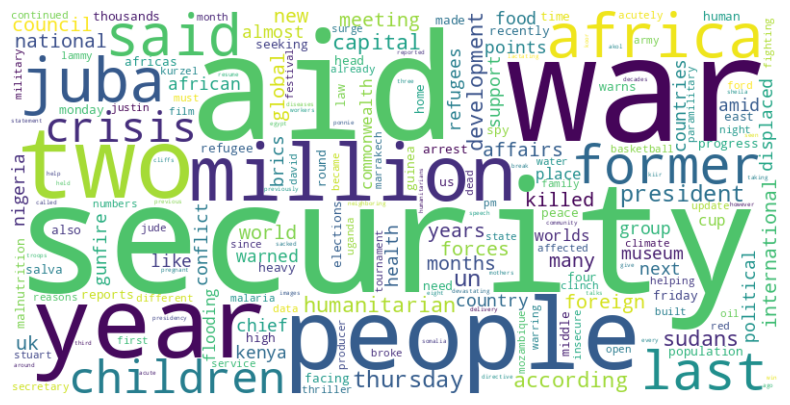


None

Concordance results for 'removed':
no matches


In [ ]:
import requests
import nltk
import pandas as pd
import numpy as np
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim_models
import re
import string
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # This is the crucial line to download punkt_tab resource

# Function to fetch news articles using NewsAPI
def fetch_news_articles(api_key, query, num_articles=100):
    url = f'https://newsapi.org/v2/everything?q={query}&pageSize={num_articles}&apiKey={api_key}'
    response = requests.get(url)
    articles = response.json()['articles']

    data = []
    for article in articles:
        title = article['title']
        description = article['description']
        content = article['content']
        data.append({'title': title, 'description': description, 'content': content})

    return pd.DataFrame(data)

# Example: Fetch news articles about South Sudan
api_key = '4ed55cd28e4349fea965dfac050ad6ef'  # Replace with your NewsAPI key
news_df = fetch_news_articles(api_key, 'South Sudan')

# Data Cleaning
def clean_text(text, stop_words):
    # Remove non-alphabetic characters, stop words, and tokenize
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    cleaned_tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned_tokens

# Prepare stop words (add custom words like 'south', 'sudan', 'chars')
stop_words = set(stopwords.words('english'))
stop_words.update(['south', 'sudan', 'chars', 'november', 'removed', 'united', 'nations'])  # Adding custom stop words

# Clean content for topic modeling
news_df['cleaned_content'] = news_df['content'].apply(lambda x: clean_text(str(x), stop_words))

# Prepare data for LDA Topic Modeling
texts = news_df['cleaned_content'].tolist()

# Create a dictionary and corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Apply LDA Model (Topic Modeling)
lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# Visualize Topics
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Display the visualization in Google Colab
pyLDAvis.display(lda_vis)

# Print topics
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

# Keyword Analysis - Find most common words across articles
# Flatten list of all words
all_words = [word for text in texts for word in text]
word_counts = Counter(all_words)

# Print top 10 most common words
print(word_counts.most_common(10))

# --- WordCloud Visualization ---
# Create a WordCloud from the most common words
wordcloud_data = dict(word_counts)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axes
plt.show()

# Contextual Analysis using nltk similar() method
def find_similar_words(word, texts):
    # Create a frequency distribution of words
    all_text = ' '.join([' '.join(text) for text in texts])
    all_tokens = word_tokenize(all_text.lower())
    text_freq = nltk.FreqDist(all_tokens)

    # Get context for a specific word
    text = nltk.Text(all_tokens)
    similar_words = text.similar(word)
    return similar_words

# Example: Find words similar to 'peace'
similar_words_to_peace = find_similar_words('peace', texts)
print(similar_words_to_peace)

# --- Additional Concordance Analysis for 'chars' ---
# Create an NLTK Text object from the combined cleaned content
all_cleaned_text = ' '.join(news_df['cleaned_content'].dropna().apply(lambda x: ' '.join(x)))
nltk_text = nltk.Text(word_tokenize(all_cleaned_text.lower()))  # Tokenize the combined text

# Perform Concordance Search for the word 'removed'
print("\nConcordance results for 'removed':")
nltk_text.concordance('removed', width=80, lines=10)  # 80-width context window,   0 lines of output


In [ ]:
# --- Count Number of Articles Mentioning "South Sudan" ---
def count_articles_with_south_sudan(news_df):
    # Convert the title, description, and content to lowercase and check for 'south sudan'
    south_sudan_mentions = news_df.apply(
        lambda row: 'south sudan' in str(row['title']).lower() or
                    'south sudan' in str(row['description']).lower() or
                    'south sudan' in str(row['content']).lower(), axis=1
    )
    return south_sudan_mentions.sum()  # Return the total count of articles mentioning 'South Sudan'

# Count the number of articles mentioning South Sudan
south_sudan_count = count_articles_with_south_sudan(news_df)
print(f"Number of articles mentioning 'South Sudan': {south_sudan_count}")

Number of articles mentioning 'South Sudan': 28


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...
Fetching page 42...
Fetching page 43...
Fetching page 44...
Fetching page 45...
Fetching page 46...
Fetching page 47...
Fetching page 48...
Fetching page 49...
Fetching page 50...
Fetching 

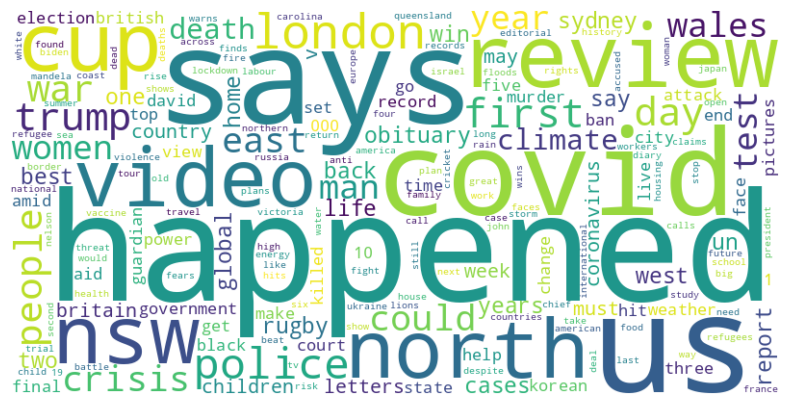

                                               title  \
0  South Sudan medics trial AI app to identify sn...   
1  ‘A journey bigger than basketball’: South Suda...   
2  UN warns that South Sudan faces ‘existential c...   
3  Londoner continues epic trans-Africa run after...   
4  Almost two dozen countries at high risk of acu...   

                                                 url                  date  \
0  https://www.theguardian.com/global-development...  2024-09-25T12:00:04Z   
1  https://www.theguardian.com/global-development...  2024-07-27T11:00:23Z   
2  https://www.theguardian.com/global-development...  2024-08-20T06:00:13Z   
3  https://www.theguardian.com/world/article/2024...  2024-06-27T13:00:07Z   
4  https://www.theguardian.com/world/2024/oct/31/...  2024-10-31T14:40:47Z   

              section                                      cleaned_title  
0  Global development  [medics, trial, ai, app, identify, snakes, imp...  
1  Global development  [journey, bigger, bas

In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Fetch articles about South Sudan from 2011 to 2024
query = 'South Sudan'
from_date = '2011-01-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
      # Add custom stopwords to the stop_words set
    custom_stopwords = ['south', 'sudan', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_south_sudan_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")


In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Function to count the number of articles mentioning "South Sudan"
# Function to count the number of articles mentioning "South Sudan"
def count_articles_with_south_sudan(df):
    # Ensure all the text is in lowercase for case-insensitive matching
    south_sudan_mentions = df.apply(
        lambda row: 'south sudan' in str(row['title']).lower() or
                    'south sudan' in str(row.get('description', '')).lower() or  # Avoid KeyError by using .get()
                    'south sudan' in str(row.get('content', '')).lower(), axis=1
    )
    return south_sudan_mentions.sum()  # Return the total count of articles mentioning 'South Sudan'

# Call the function after fetching and processing the articles
south_sudan_count = count_articles_with_south_sudan(df)
print(f"Number of articles mentioning 'South Sudan': {south_sudan_count}")

# Fetch articles about South Sudan from 2022 to 2024
query = 'South Sudan'
from_date = '2013-01-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords to the stop_words set
    custom_stopwords = ['south', 'sudan', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Count the number of articles mentioning "South Sudan"
    south_sudan_count = count_articles_with_south_sudan(df)
    print(f"Number of articles mentioning 'South Sudan': {south_sudan_count}")

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_south_sudan_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")

# List of keywords to look for (can expand as needed)
keywords = ['peace agreement', 'conflict', 'humanitarian aid', 'aid', 'peace', 'war', 'refugee', 'violence']

# Function to count keyword occurrences in a list of articles
def count_keywords_in_articles(articles, keywords):
    keyword_counts = {keyword: 0 for keyword in keywords}

    # Iterate over the articles and check for keyword occurrences
    for article in articles:
        for keyword in keywords:
            if keyword.lower() in article.lower():  # Check if keyword exists in article
                keyword_counts[keyword] += 1

    return keyword_counts

# Start measuring time
start_time = time.time()

# Set a time limit (in seconds)
time_limit = 60  # 60 seconds time limit for processing

# Example: Assume 'df' is a DataFrame with article titles (replace this with actual DataFrame loading logic)
# The 'df' DataFrame should already have the cleaned titles ready for processing
# Here I am assuming the 'cleaned_title' column contains cleaned article titles
articles = df['cleaned_title'].apply(lambda x: ' '.join(x)).tolist()  # Join the list of words into a single string

# Check the time elapsed so far
elapsed_time = time.time() - start_time
if elapsed_time > time_limit:
    print(f"Time limit exceeded during data processing. Elapsed time: {elapsed_time:.2f} seconds")
else:
    # Count keyword occurrences
    keyword_counts = count_keywords_in_articles(articles, keywords)

    # Check the time elapsed
    elapsed_time = time.time() - start_time
    if elapsed_time > time_limit:
        print(f"Time limit exceeded during keyword counting. Elapsed time: {elapsed_time:.2f} seconds")
    else:
        # Print keyword frequency counts
        print("Keyword Frequencies:")
        for keyword, count in keyword_counts.items():
            print(f"{keyword}: {count}")

        # --- Bar Chart Visualization ---
        plt.figure(figsize=(10, 6))
        plt.bar(keyword_counts.keys(), keyword_counts.values(), color='skyblue')
        plt.title('Keyword Frequency in South Sudan Articles')
        plt.xlabel('Keywords')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # --- WordCloud Visualization ---
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(keyword_counts)

        # Plot the WordCloud
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')  # Hide axes
        plt.title('Keyword WordCloud for South Sudan Articles')
        plt.show()

# Measure total time elapsed
total_elapsed_time = time.time() - start_time
print(f"Total time elapsed: {total_elapsed_time:.2f} seconds")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


NameError: name 'df' is not defined

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fetching page 1...
Fetching page 2...
Error: 429
Number of articles mentioning 'Ukraine': 50
LDA Topics:
(0, '0.062*"war" + 0.054*"russia" + 0.032*"happened" + 0.024*"us" + 0.024*"briefing"')
(1, '0.069*"war" + 0.054*"briefing" + 0.031*"says" + 0.031*"russia" + 0.016*"trump"')
(2, '0.051*"war" + 0.040*"briefing" + 0.029*"russia" + 0.023*"russian" + 0.023*"says"')
(3, '0.051*"war" + 0.041*"briefing" + 0.021*"first" + 0.012*"christopher" + 0.012*"chivvis"')
(4, '0.038*"russia" + 0.038*"war" + 0.031*"briefing" + 0.023*"000" + 0.016*"missile"')


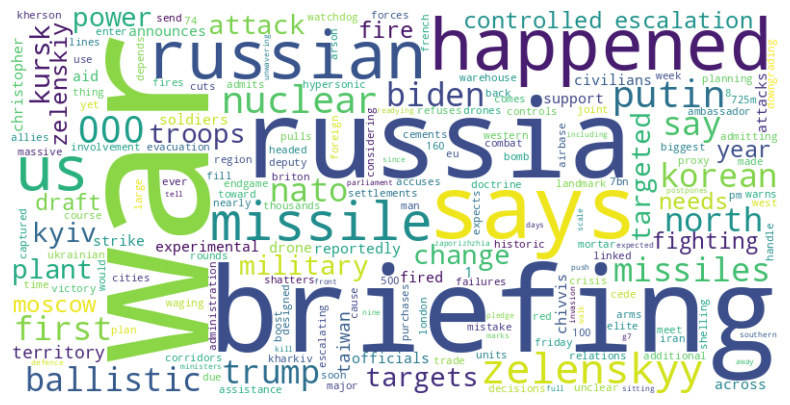

                                               title  \
0  Ukraine war briefing: Ukraine marks 1,000 days...   
1  Ukraine war briefing: Ukraine parliament repor...   
2  Ukraine war briefing: Russian attacks kill nin...   
3  Ukraine war briefing: G7 defence ministers ple...   
4  Ukraine war briefing: Don’t walk away from Ukr...   

                                                 url                  date  \
0  https://www.theguardian.com/world/2024/nov/19/...  2024-11-19T01:27:07Z   
1  https://www.theguardian.com/world/2024/nov/22/...  2024-11-22T01:28:05Z   
2  https://www.theguardian.com/world/2024/oct/27/...  2024-10-27T01:59:46Z   
3  https://www.theguardian.com/world/2024/oct/20/...  2024-10-20T01:25:56Z   
4  https://www.theguardian.com/world/2024/nov/11/...  2024-11-11T01:17:55Z   

      section                                      cleaned_title  
0  World news  [war, briefing, marks, 1, 000, days, since, fu...  
1  World news  [war, briefing, parliament, reportedly, postp

In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Function to count the number of articles mentioning "Ukraine"
def count_articles_with_ukraine(df):
    # Ensure all the text is in lowercase for case-insensitive matching
    ukraine_mentions = df.apply(
        lambda row: 'ukraine' in str(row['title']).lower() or
                    'ukraine' in str(row.get('description', '')).lower() or  # Avoid KeyError by using .get()
                    'ukraine' in str(row.get('content', '')).lower(), axis=1
    )
    return ukraine_mentions.sum()  # Return the total count of articles mentioning 'Ukraine'

# Fetch articles about Ukraine from 2022 to 2024
query = 'Ukraine'
from_date = '2023-10-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords to the stop_words set
    custom_stopwords = ['ukraine', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Count the number of articles mentioning "Ukraine"
    ukraine_count = count_articles_with_ukraine(df)
    print(f"Number of articles mentioning 'Ukraine': {ukraine_count}")

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_ukraine_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fetching page 1...
Fetching page 2...
Error: 429
Number of articles mentioning 'Palestine' or 'Gaza': 37
LDA Topics:
(0, '0.029*"pro" + 0.022*"war" + 0.022*"middle" + 0.022*"east" + 0.015*"public"')
(1, '0.026*"pro" + 0.026*"un" + 0.013*"offence" + 0.013*"racial" + 0.013*"placard"')
(2, '0.019*"israel" + 0.018*"back" + 0.010*"protest" + 0.010*"review" + 0.010*"two"')
(3, '0.016*"israeli" + 0.016*"leaders" + 0.016*"students" + 0.016*"university" + 0.016*"protests"')
(4, '0.028*"pro" + 0.015*"protesters" + 0.015*"rally" + 0.015*"protests" + 0.015*"palestinian"')


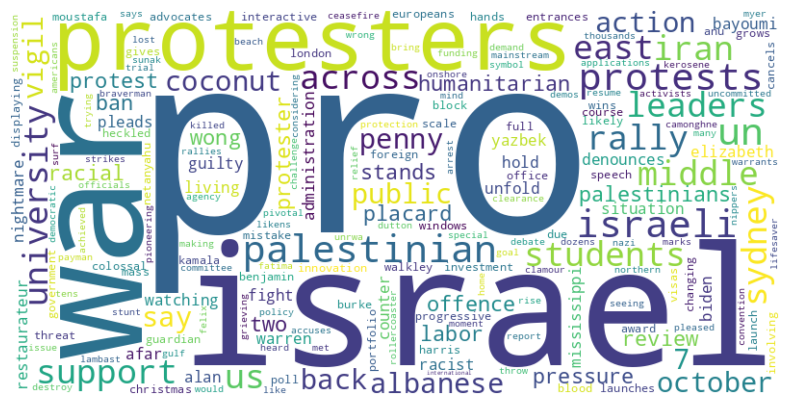

                                               title  \
0  ‘Progressive except for Palestine’: how a tech...   
1  ‘We play every game with heart’: Palestine mee...   
2  Amsterdam police detain pro-Palestine proteste...   
3  ‘A new abyss’: Gaza and the hundred years’ war...   
4  US professors face discipline and investigatio...   

                                                 url                  date  \
0  https://www.theguardian.com/technology/2024/de...  2024-12-03T15:00:53Z   
1  https://www.theguardian.com/football/article/2...  2024-06-10T15:00:18Z   
2  https://www.theguardian.com/world/2024/nov/13/...  2024-11-13T21:58:25Z   
3  https://www.theguardian.com/world/2024/apr/11/...  2024-04-11T04:00:22Z   
4  https://www.theguardian.com/us-news/2024/oct/2...  2024-10-24T12:00:49Z   

      section                                      cleaned_title  
0  Technology  [progressive, except, tech, charity, imploded,...  
1    Football  [play, every, game, heart, meet, socceroos, m

In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Function to count the number of articles mentioning "Palestine" or "Gaza"
def count_articles_with_palestine_or_gaza(df):
    # Ensure all the text is in lowercase for case-insensitive matching
    palestine_or_gaza_mentions = df.apply(
        lambda row: 'palestine' in str(row['title']).lower() or
                    'gaza' in str(row['title']).lower() or
                    'palestine' in str(row.get('description', '')).lower() or
                    'gaza' in str(row.get('description', '')).lower() or
                    'palestine' in str(row.get('content', '')).lower() or
                    'gaza' in str(row.get('content', '')).lower(), axis=1
    )
    return palestine_or_gaza_mentions.sum()  # Return the total count of articles mentioning 'Palestine' or 'Gaza'

# Fetch articles about Palestine or Gaza from 2022 to 2024
query = 'Palestine OR Gaza'
from_date = '2023-10-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords to the stop_words set
    custom_stopwords = ['palestine', 'gaza', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Count the number of articles mentioning "Palestine" or "Gaza"
    palestine_or_gaza_count = count_articles_with_palestine_or_gaza(df)
    print(f"Number of articles mentioning 'Palestine' or 'Gaza': {palestine_or_gaza_count}")

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_palestine_gaza_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fetching page 1...
Fetching page 2...
Fetching page 3...
Error: 429
Number of articles mentioning 'Israel': 100
LDA Topics:
(0, '0.027*"gaza" + 0.023*"happened" + 0.023*"war" + 0.020*"says" + 0.020*"defence"')
(1, '0.045*"hezbollah" + 0.023*"ceasefire" + 0.015*"lebanon" + 0.012*"launches" + 0.012*"beirut"')
(2, '0.020*"us" + 0.020*"attack" + 0.014*"iran" + 0.014*"7" + 0.014*"october"')
(3, '0.036*"lebanon" + 0.022*"us" + 0.022*"ceasefire" + 0.022*"hezbollah" + 0.015*"says"')
(4, '0.029*"gaza" + 0.029*"attack" + 0.019*"iran" + 0.015*"attacks" + 0.015*"ceasefire"')


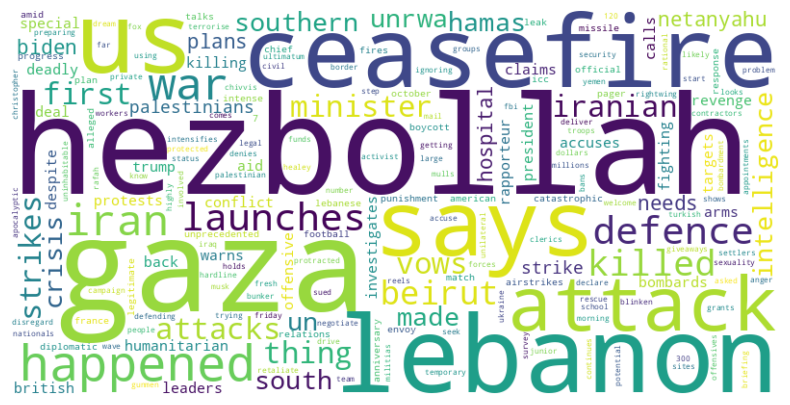

                                               title  \
0  First Thing: Israel-Hezbollah ceasefire in Leb...   
1  Israel-Gaza war: Israel issues massive evacuat...   
2      Israel launches rare strike on central Beirut   
3  Why has Israel detained American journalist Je...   
4  Israel abducts alleged Hezbollah official in u...   

                                                 url                  date  \
0  https://www.theguardian.com/us-news/2024/nov/2...  2024-11-27T12:18:17Z   
1  https://www.theguardian.com/world/live/2024/au...  2024-08-11T15:00:13Z   
2  https://www.theguardian.com/world/2024/sep/30/...  2024-09-30T13:57:02Z   
3  https://www.theguardian.com/commentisfree/2024...  2024-10-11T16:00:02Z   
4  https://www.theguardian.com/world/2024/nov/02/...  2024-11-02T19:30:31Z   

      section                                      cleaned_title  
0     US news  [first, thing, hezbollah, ceasefire, lebanon, ...  
1  World news  [gaza, war, issues, massive, evacuation, orde

In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Function to count the number of articles mentioning "Israel"
def count_articles_with_israel(df):
    # Ensure all the text is in lowercase for case-insensitive matching
    israel_mentions = df.apply(
        lambda row: 'israel' in str(row['title']).lower() or
                    'israel' in str(row.get('description', '')).lower() or
                    'israel' in str(row.get('content', '')).lower(), axis=1
    )
    return israel_mentions.sum()  # Return the total count of articles mentioning 'Israel'

# Fetch articles about Israel from 2022 to 2024
query = 'Israel'
from_date = '2023-10-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords to the stop_words set
    custom_stopwords = ['israel', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Count the number of articles mentioning "Israel"
    israel_count = count_articles_with_israel(df)
    print(f"Number of articles mentioning 'Israel': {israel_count}")

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_israel_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fetching page 1...
Fetching page 2...
Fetching page 3...
Error: 429
Number of articles mentioning 'South Sudan': 10
LDA Topics:
(0, '0.013*"war" + 0.009*"north" + 0.009*"children" + 0.009*"observer" + 0.005*"un"')
(1, '0.010*"law" + 0.007*"civil" + 0.007*"wales" + 0.007*"president" + 0.007*"carolina"')
(2, '0.013*"people" + 0.009*"happened" + 0.009*"enough" + 0.009*"disaster" + 0.009*"borthwick"')
(3, '0.011*"weather" + 0.008*"crisis" + 0.008*"east" + 0.008*"two" + 0.008*"heatwave"')
(4, '0.008*"run" + 0.008*"end" + 0.008*"war" + 0.008*"say" + 0.004*"crisis"')


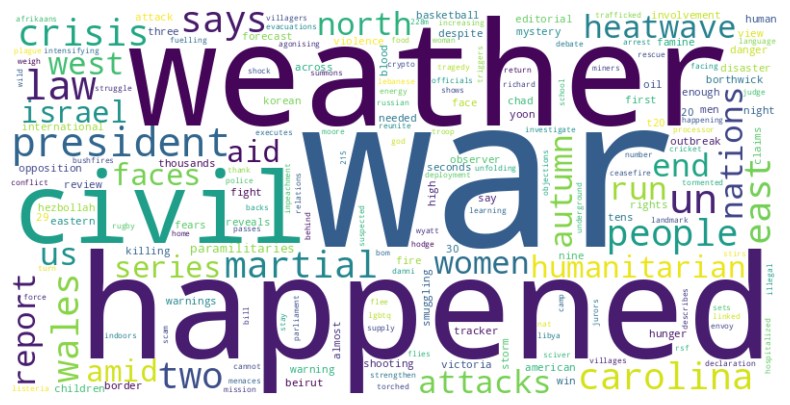

                                               title  \
0  South Sudan medics trial AI app to identify sn...   
1  ‘A journey bigger than basketball’: South Suda...   
2  UN warns that South Sudan faces ‘existential c...   
3  Londoner continues epic trans-Africa run after...   
4  Almost two dozen countries at high risk of acu...   

                                                 url                  date  \
0  https://www.theguardian.com/global-development...  2024-09-25T12:00:04Z   
1  https://www.theguardian.com/global-development...  2024-07-27T11:00:23Z   
2  https://www.theguardian.com/global-development...  2024-08-20T06:00:13Z   
3  https://www.theguardian.com/world/article/2024...  2024-06-27T13:00:07Z   
4  https://www.theguardian.com/world/2024/oct/31/...  2024-10-31T14:40:47Z   

              section                                      cleaned_title  
0  Global development  [medics, trial, ai, app, identify, snakes, imp...  
1  Global development  [journey, bigger, bas

In [ ]:
import requests
import pandas as pd
import time
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Your Guardian API Key
api_key = 'a267dd78-258b-4daa-8951-8ddb53102242'  # Replace with your Guardian API key

# Download NLTK resources
nltk.download('stopwords')

# Function to fetch news articles from The Guardian API
def fetch_guardian_articles(api_key, query, from_date, to_date, page=1, page_size=50):
    url = f'https://content.guardianapis.com/search'

    params = {
        'q': query,
        'from-date': from_date,
        'to-date': to_date,
        'api-key': api_key,
        'page': page,
        'page-size': page_size
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}")
        return None

# Function to parse the articles from the response
def parse_articles(response):
    articles = []

    # Check if the response contains the expected data
    if 'response' in response and 'results' in response['response']:
        for result in response['response']['results']:
            title = result.get('webTitle', 'No title')
            url = result.get('webUrl', 'No URL')
            date = result.get('webPublicationDate', 'No date')
            section = result.get('sectionName', 'No section')

            articles.append({
                'title': title,
                'url': url,
                'date': date,
                'section': section
            })
    else:
        print("No articles found or unexpected response structure.")
    return articles

# Function to fetch multiple pages of results from The Guardian
def fetch_all_articles(api_key, query, from_date, to_date):
    all_articles = []
    page = 1
    while True:
        print(f"Fetching page {page}...")
        response = fetch_guardian_articles(api_key, query, from_date, to_date, page=page, page_size=50)

        if response is None or 'response' not in response or 'results' not in response['response']:
            break

        articles = parse_articles(response)
        all_articles.extend(articles)

        # Check if we have fetched all articles (less than page_size)
        if len(articles) < 50:
            break

        page += 1
        time.sleep(1)  # To avoid hitting the API rate limit

    return all_articles

# Function to count the number of articles mentioning "South Sudan"
def count_articles_with_south_sudan(df):
    # Ensure all the text is in lowercase for case-insensitive matching
    south_sudan_mentions = df.apply(
        lambda row: 'south sudan' in str(row['title']).lower() or
                    'south sudan' in str(row.get('description', '')).lower() or
                    'south sudan' in str(row.get('content', '')).lower(), axis=1
    )
    return south_sudan_mentions.sum()  # Return the total count of articles mentioning 'South Sudan'

# Fetch articles about South Sudan from 2013 to 2024
query = 'South Sudan'
from_date = '2013-01-01'
to_date = '2024-12-31'

articles = fetch_all_articles(api_key, query, from_date, to_date)

# Check if any articles were fetched
if articles:
    # Convert the list of articles to a DataFrame for analysis
    df = pd.DataFrame(articles)

    # Data Cleaning for text processing
    stop_words = set(stopwords.words('english'))
    # Add custom stopwords to the stop_words set
    custom_stopwords = ['south', 'sudan', 'africa', 'world', 'uk', 'australia', 'china',
                        'african', 'australian', 'england', 'new', 'zealand', 'korea']

    stop_words.update(custom_stopwords)  # Adding custom stopwords

    def clean_text(text):
        # Remove punctuation and tokenize text
        text = ''.join([char if char.isalnum() else ' ' for char in text]).lower()
        tokens = text.split()
        return [word for word in tokens if word not in stop_words]

    # Clean the article titles
    df['cleaned_title'] = df['title'].apply(lambda x: clean_text(str(x)))

    # Count the number of articles mentioning "South Sudan"
    south_sudan_count = count_articles_with_south_sudan(df)
    print(f"Number of articles mentioning 'South Sudan': {south_sudan_count}")

    # Prepare data for LDA topic modeling
    texts = df['cleaned_title'].tolist()

    # Create a dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Apply LDA Model (Topic Modeling)
    lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

    # Print topics
    topics = lda_model.print_topics(num_words=5)
    print("LDA Topics:")
    for topic in topics:
        print(topic)

    # WordCloud Visualization based on the most common words
    all_words = [word for text in texts for word in text]
    wordcloud_data = dict(pd.Series(all_words).value_counts())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Remove axes
    plt.show()

    # Save the articles to a CSV file
    df.to_csv('guardian_south_sudan_articles.csv', index=False)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print("No articles fetched. Check API key or query parameters.")
